Using device: cpu


100%|██████████| 170M/170M [01:40<00:00, 1.70MB/s]


Train batches: 196 | Test batches: 40

 Epoch      Recon     Sparse      Train       Test


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


     1    0.64434    0.66719    0.64501    0.53358
     2    0.50910    0.67452    0.50978    0.49605
     3    0.47692    0.68303    0.47760    0.46874
     4    0.45802    0.69175    0.45871    0.45677
     5    0.44724    0.70028    0.44794    0.45194
     6    0.43813    0.70809    0.43884    0.44443
     7    0.43269    0.71569    0.43340    0.43298
     8    0.42712    0.72253    0.42784    0.43373
     9    0.42289    0.72890    0.42362    0.42968
    10    0.41938    0.73507    0.42012    0.43330
    11    0.40884    0.73921    0.40957    0.41453
    12    0.40713    0.74133    0.40787    0.41250
    13    0.40560    0.74311    0.40635    0.41187
    14    0.40397    0.74512    0.40471    0.40869
    15    0.40223    0.74706    0.40298    0.40735
    16    0.40088    0.74903    0.40163    0.40708
    17    0.39927    0.75086    0.40002    0.40942
    18    0.39797    0.75249    0.39872    0.40294
    19    0.39593    0.75396    0.39669    0.40110
    20    0.39504    0.75520   

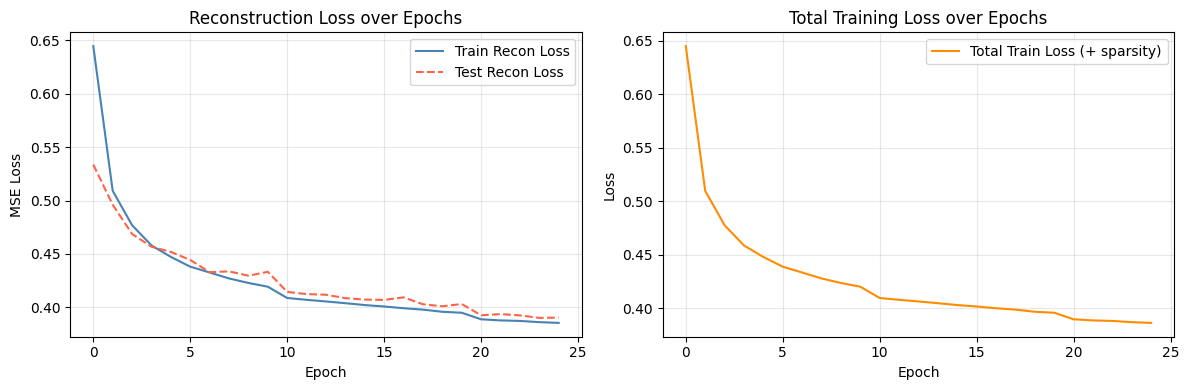

Saved → training_curves.png


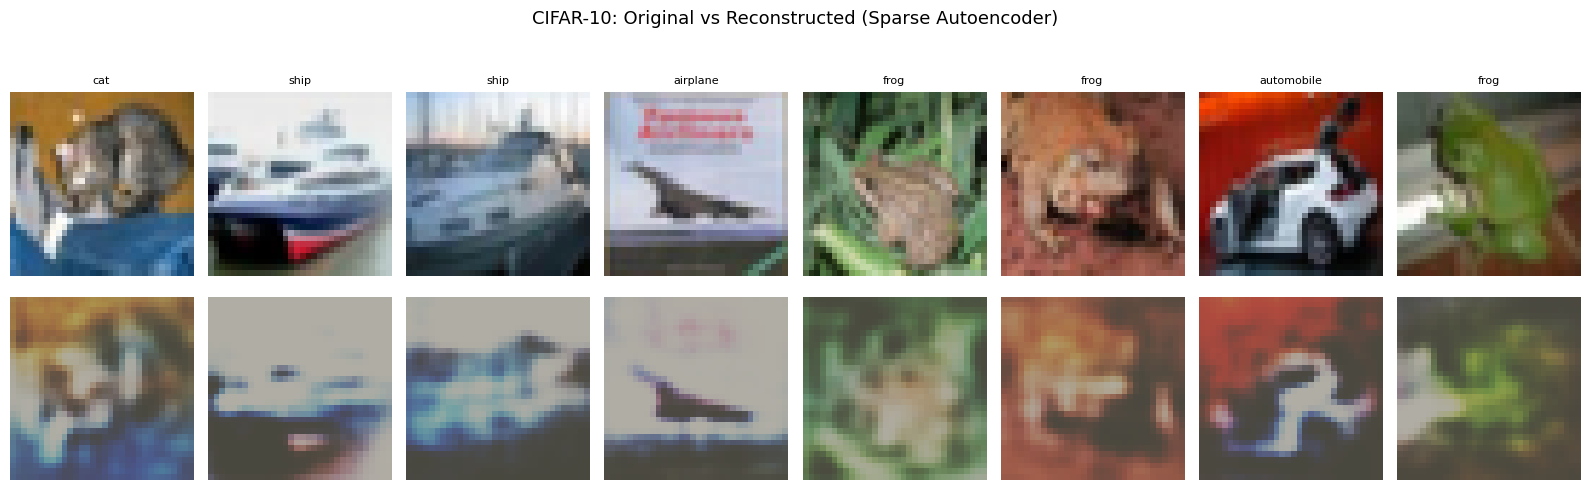

Saved → reconstructions.png

──────────────────────────────────────────────
  Sparsity Experiment: varying β (5 epochs each)
──────────────────────────────────────────────
  β=0.0000  |  Test Recon: 0.44246  |  Active Units: 0.597
  β=0.0001  |  Test Recon: 0.44251  |  Active Units: 0.599
  β=0.0010  |  Test Recon: 0.44262  |  Active Units: 0.598
  β=0.0100  |  Test Recon: 0.44523  |  Active Units: 0.577
  β=0.1000  |  Test Recon: 0.45056  |  Active Units: 0.441


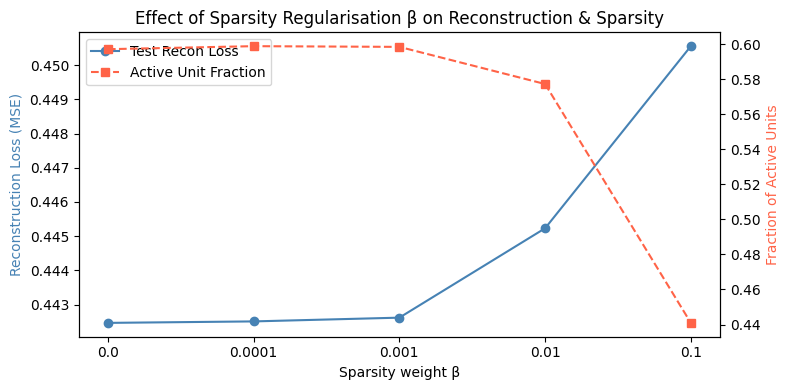

Saved → sparsity_experiment.png

✅  All tasks complete.


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),   # CIFAR-10 channel means
                         (0.2023, 0.1994, 0.2010)),   # CIFAR-10 channel stds
    transforms.Lambda(lambda x: x.view(-1))           # flatten → (3072,)
])

train_dataset = datasets.CIFAR10(root="./data", train=True,  download=True, transform=transform)
test_dataset  = datasets.CIFAR10(root="./data", train=False, download=True, transform=transform)

BATCH_SIZE = 256
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"Train batches: {len(train_loader)} | Test batches: {len(test_loader)}")

#  2.  Sparse Autoencoder Model
class SparseAutoencoder(nn.Module):
    """
    Architecture
    ────────────
    Encoder:  3072 → 1024 → 512  (ReLU activations for natural sparsity)
    Latent:   512-dim code  (sparsity is imposed here)
    Decoder:  512 → 1024 → 3072  (Tanh on final layer — matches normalised range)

    Sparsity penalty: KL-divergence between desired average activation ρ
    and the actual average activation ρ̂ per hidden unit.
    """

    def __init__(self, input_dim: int = 3072,
                 hidden1: int = 1024,
                 hidden2: int = 512):
        super().__init__()

        # ── Encoder ──────────────────────────────
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden1),
            nn.BatchNorm1d(hidden1),
            nn.ReLU(inplace=True),
            nn.Linear(hidden1, hidden2),
            nn.BatchNorm1d(hidden2),
            nn.ReLU(inplace=True),   # ReLU → many activations stay 0 (sparsity)
        )

        # ── Decoder ──────────────────────────────
        self.decoder = nn.Sequential(
            nn.Linear(hidden2, hidden1),
            nn.BatchNorm1d(hidden1),
            nn.ReLU(inplace=True),
            nn.Linear(hidden1, input_dim),
            nn.Tanh(),               # output ∈ (-1, 1) matches normalised input
        )

        # Weight initialisation (Xavier)
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        code = self.encoder(x)       # latent representation
        recon = self.decoder(code)   # reconstruction
        return recon, code

#  3.  Sparsity Penalty (KL divergence)
def kl_divergence_sparsity(code: torch.Tensor, rho: float = 0.05) -> torch.Tensor:
    """
    KL( rho || rho_hat )  averaged over all hidden units.

    rho     : desired (target) average activation (typically small, e.g. 0.05)
    rho_hat : actual average activation of each hidden unit across the batch
    """
    rho_hat = torch.mean(torch.sigmoid(code), dim=0)   # (hidden_dim,)
    rho_hat = torch.clamp(rho_hat, 1e-6, 1 - 1e-6)    # numerical stability
    rho_t   = torch.full_like(rho_hat, rho)
    kl = rho_t * torch.log(rho_t / rho_hat) + \
         (1 - rho_t) * torch.log((1 - rho_t) / (1 - rho_hat))
    return kl.mean()

#  4.  Training Loop
def train_one_epoch(model, loader, optimizer, beta, rho):
    model.train()
    total_recon, total_sparse, total_loss = 0.0, 0.0, 0.0

    for imgs, _ in loader:
        imgs = imgs.to(device)

        recon, code = model(imgs)

        # Reconstruction loss (MSE)
        recon_loss   = nn.functional.mse_loss(recon, imgs)
        # Sparsity penalty
        sparse_loss  = kl_divergence_sparsity(code, rho)
        # Combined loss
        loss = recon_loss + beta * sparse_loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_recon  += recon_loss.item()
        total_sparse += sparse_loss.item()
        total_loss   += loss.item()

    n = len(loader)
    return total_recon / n, total_sparse / n, total_loss / n


def evaluate(model, loader, beta, rho):
    model.eval()
    total_recon = 0.0
    with torch.no_grad():
        for imgs, _ in loader:
            imgs = imgs.to(device)
            recon, code = model(imgs)
            total_recon += nn.functional.mse_loss(recon, imgs).item()
    return total_recon / len(loader)

#  5.  Hyperparameters & Training
EPOCHS        = 25
LEARNING_RATE = 1e-3
BETA          = 1e-3   # sparsity weight
RHO           = 0.05   # target average activation

model     = SparseAutoencoder().to(device)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-5)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)
print(f"{'Epoch':>6} {'Recon':>10} {'Sparse':>10} {'Train':>10} {'Test':>10}")

history = {"train_recon": [], "train_total": [], "test_recon": []}

for epoch in range(1, EPOCHS + 1):
    r_loss, s_loss, t_loss = train_one_epoch(model, train_loader, optimizer, BETA, RHO)
    test_r                  = evaluate(model, test_loader, BETA, RHO)
    scheduler.step()

    history["train_recon"].append(r_loss)
    history["train_total"].append(t_loss)
    history["test_recon"].append(test_r)

    print(f"{epoch:>6} {r_loss:>10.5f} {s_loss:>10.5f} {t_loss:>10.5f} {test_r:>10.5f}")



#  6.  Plot Training Curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history["train_recon"], label="Train Recon Loss", color="steelblue")
axes[0].plot(history["test_recon"],  label="Test Recon Loss",  color="tomato", linestyle="--")
axes[0].set_title("Reconstruction Loss over Epochs")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("MSE Loss")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history["train_total"], label="Total Train Loss (+ sparsity)", color="darkorange")
axes[1].set_title("Total Training Loss over Epochs")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Loss")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("training_curves.png", dpi=150)
plt.show()
print("Saved → training_curves.png")
#  7.  Visualise Original vs Reconstructed
CIFAR10_CLASSES = ["airplane","automobile","bird","cat","deer",
                   "dog","frog","horse","ship","truck"]

# Un-normalise helper  (reverses the Normalize transform)
_mean = torch.tensor([0.4914, 0.4822, 0.4465])
_std  = torch.tensor([0.2023, 0.1994, 0.2010])

def unnormalize(flat_tensor):
    """flat_tensor: shape (3072,) on CPU"""
    img = flat_tensor.view(3, 32, 32)
    img = img * _std[:, None, None] + _mean[:, None, None]
    return img.clamp(0, 1).permute(1, 2, 0).numpy()   # HWC for imshow


model.eval()
test_iter = iter(test_loader)
sample_imgs, sample_labels = next(test_iter)
sample_imgs = sample_imgs.to(device)

with torch.no_grad():
    recon_imgs, _ = model(sample_imgs)

N = 8   # number of examples to display
fig, axes = plt.subplots(2, N, figsize=(2 * N, 5))

for i in range(N):
    orig  = unnormalize(sample_imgs[i].cpu())
    recon = unnormalize(recon_imgs[i].cpu())

    axes[0, i].imshow(orig);  axes[0, i].axis("off")
    axes[1, i].imshow(recon); axes[1, i].axis("off")

    axes[0, i].set_title(CIFAR10_CLASSES[sample_labels[i]], fontsize=8)

axes[0, 0].set_ylabel("Original",      fontsize=11, labelpad=40)
axes[1, 0].set_ylabel("Reconstructed", fontsize=11, labelpad=40)

plt.suptitle("CIFAR-10: Original vs Reconstructed (Sparse Autoencoder)", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("reconstructions.png", dpi=150, bbox_inches="tight")
plt.show()
#  8.  Sparsity Experiment  (β sweep)
print("\n──────────────────────────────────────────────")
print("  Sparsity Experiment: varying β (5 epochs each)")
print("──────────────────────────────────────────────")

BETA_VALUES     = [0.0, 1e-4, 1e-3, 1e-2, 1e-1]
EXPERIMENT_EPOCHS = 5
results = {}

for beta_val in BETA_VALUES:
    exp_model = SparseAutoencoder().to(device)
    exp_opt   = optim.Adam(exp_model.parameters(), lr=1e-3)

    for _ in range(EXPERIMENT_EPOCHS):
        train_one_epoch(exp_model, train_loader, exp_opt, beta_val, RHO)

    test_loss = evaluate(exp_model, test_loader, beta_val, RHO)

    # Average activation sparsity on first test batch
    exp_model.eval()
    with torch.no_grad():
        imgs_b, _ = next(iter(test_loader))
        _, code_b = exp_model(imgs_b.to(device))
        act_fraction = (code_b > 0).float().mean().item()

    results[beta_val] = {"test_recon": test_loss, "active_fraction": act_fraction}
    print(f"  β={beta_val:.4f}  |  Test Recon: {test_loss:.5f}  |  Active Units: {act_fraction:.3f}")

# Plot sparsity experiment
betas   = list(results.keys())
recons  = [results[b]["test_recon"]     for b in betas]
actives = [results[b]["active_fraction"] for b in betas]

fig, ax1 = plt.subplots(figsize=(8, 4))
ax2 = ax1.twinx()

ax1.plot(range(len(betas)), recons,  "o-", color="steelblue", label="Test Recon Loss")
ax2.plot(range(len(betas)), actives, "s--", color="tomato",  label="Active Unit Fraction")

ax1.set_xticks(range(len(betas)))
ax1.set_xticklabels([str(b) for b in betas])
ax1.set_xlabel("Sparsity weight β")
ax1.set_ylabel("Reconstruction Loss (MSE)", color="steelblue")
ax2.set_ylabel("Fraction of Active Units",  color="tomato")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.title("Effect of Sparsity Regularisation β on Reconstruction & Sparsity")
plt.tight_layout()
plt.savefig("sparsity_experiment.png", dpi=150)
plt.show()